# F1 four-mode model research v2

Reproducible extraction of the final same-season Qualifying, Race, Best-Lap, telemetry, and Live evidence. The event is the independent evaluation unit; model selection, calibration, and replay blocks are kept distinct. Forecasts are target-isolated within each run, but R7-R9 are post-development replay diagnostics rather than pristine prospective promotion evidence.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from packages.f1.orchestration.evidence_validation import validate_artifact_provenance

ROOT = Path.cwd().resolve()
if not (ROOT / 'packages' / 'f1').exists():
    raise RuntimeError(f'execute from repository root, observed {ROOT}')
EVIDENCE = ROOT / 'docs' / 'research' / 'evidence'
ASSETS = ROOT / 'docs' / 'research' / 'assets'
EVIDENCE.mkdir(parents=True, exist_ok=True)
ASSETS.mkdir(parents=True, exist_ok=True)


In [2]:
ARTIFACTS = {
    'qualifying': ROOT / 'artifacts/backtests/f1/qualifying/shared_latent_same_season_v2_20260713.json',
    'qualifying_probability': ROOT / 'artifacts/backtests/f1/qualifying/shared_latent_same_season_probability_audit_v4_20260714.json',
    'race_main': ROOT / 'artifacts/backtests/f1/race_final_position/survival_order_same_season_v8_selector_safe_20260713.json',
    'race_certified': ROOT / 'artifacts/backtests/f1/race_final_position/certified_grid_prior_state_ablation_v1_20260714.json',
    'best_lap': ROOT / 'artifacts/backtests/f1/best_estimated_lap/same_season_event_gated_v18_tcn_matrix_bound_20260714.json',
    'same_season_residual': ROOT / 'artifacts/backtests/f1/research/same_season_latent_residual_frozen_audit_v2_20260713.json',
    'telemetry_sequence': ROOT / 'artifacts/backtests/f1/telemetry/prequal_telemetry_residual_sequence_v6_repository_bound_2026.json',
    'telemetry_tcn': ROOT / 'artifacts/backtests/f1/telemetry/prequal_telemetry_true_tcn_research_v2_2026.json',
    'telemetry_tcn_matrix': ROOT / 'artifacts/backtests/f1/telemetry/prequal_telemetry_tcn_sensitivity_matrix_v1_2026.json',
    'live_next_lap': ROOT / 'artifacts/backtests/f1/live_next_lap/2026_walk_forward_ssm_naive_emitted_forecast_v6_20260714.json',
    'live_strategy_replay': ROOT / 'artifacts/backtests/f1/live_strategy/live_strategy_replay_audit_v1_20260714.json',
}
EXPECTED_SHA256 = {
    'qualifying': '9a14686c8d1dcf44489d8af64955e4bd06e154bb5164ecedb79fec5faeae70da',
    'qualifying_probability': '082387f0afe451c1a5d1b9c0634e0545330e886ee8f0161aebb3bf8428c27a20',
    'race_main': '92c0179d7312367ecda253c0a8b6427721267efe572b3051a9cfc9ed25d69639',
    'race_certified': 'b85f0312eead971e8f1ea3669247d89091d556352ba21eca0b057f1ef2500dbd',
    'best_lap': 'dcc0a2bc5d89aa1a89400598eb38f7dfca5334712b839f4fd46442d1c2029133',
    'same_season_residual': '757c57d15facd1a789437db783899717da2b81707a41a3d250e9392c5d18b479',
    'telemetry_sequence': '1743e0a5a492f05ec0507092b192332e33f22102a585af45a1a051472c87e4f8',
    'telemetry_tcn': '9c98244bd4c854b86850bda00a8dfd2454a845a2cbf83b1944c21e3bff09f999',
    'telemetry_tcn_matrix': 'd148d512376bc7c14479ff48f07c73181fe7cf033b5a2eea8936d0067ef35197',
    'live_next_lap': '03adf04ac1649a5c3581a4d5bbe9d91693e5f10cd95ac774dfda5918c738af03',
    'live_strategy_replay': 'fbcf073b472f9a39a151c438712f354716467b5e068dbbdb166781ff560cff8c',
}
EXPECTED_SCHEMA_VERSION = {
    'qualifying': 'f1_shared_qualifying_latent_event_block_v6',
    'qualifying_probability': 'f1_qualifying_probability_temperature_sinkhorn_audit_v3',
    'race_main': 'f1_race_survival_order_event_block_v8',
    'race_certified': 'f1_race_certified_grid_prior_ablation_v1',
    'best_lap': 'f1_best_estimated_lap_shared_latent_v11',
    'same_season_residual': 'f1_same_season_latent_residual_research_v3',
    'telemetry_sequence': 'f1_prequal_telemetry_residual_research_v4',
    'telemetry_tcn': 'f1_prequal_telemetry_true_tcn_research_v2',
    'telemetry_tcn_matrix': 'f1_prequal_telemetry_tcn_sensitivity_matrix_v1',
    'live_next_lap': 'f1_live_next_lap_walk_forward_emitted_forecast_v3',
    'live_strategy_replay': 'f1_live_strategy_replay_audit_v1',
}
missing = [str(path) for path in ARTIFACTS.values() if not path.exists()]
if missing:
    raise FileNotFoundError('missing final artifacts: ' + ', '.join(missing))
payloads = {name: json.loads(path.read_text(encoding='utf-8')) for name, path in ARTIFACTS.items()}
observed_sha256 = {name: hashlib.sha256(path.read_bytes()).hexdigest() for name, path in ARTIFACTS.items()}
mismatched = {name: (EXPECTED_SHA256[name], observed) for name, observed in observed_sha256.items() if observed != EXPECTED_SHA256[name]}
if mismatched:
    raise RuntimeError(f'frozen artifact digest mismatch: {mismatched}')
provenance_checks = {
    name: validate_artifact_provenance(
        root=ROOT,
        artifact_path=path,
        expected_sha256=EXPECTED_SHA256[name],
        expected_schema_version=EXPECTED_SCHEMA_VERSION[name],
    )
    for name, path in ARTIFACTS.items()
}
artifact_register = pd.DataFrame([
    {
        'artifact': name,
        'path': str(path.relative_to(ROOT)),
        'schema_version': payloads[name].get('schema_version'),
        'sha256': observed_sha256[name],
        **provenance_checks[name],
    }
    for name, path in ARTIFACTS.items()
]).sort_values('artifact').reset_index(drop=True)
artifact_register

,artifact,path,schema_version,sha256,artifact_sha256_valid,schema_version_valid,implementation_manifest_direct_entries,input_manifest_direct_entries,implementation_manifest_files,input_manifest_files,transitive_file_count,nested_json_count,aggregate_manifest_digest_count,implementation_manifest_valid,input_manifest_valid,aggregate_manifest_digests_valid,provenance_closure_status
0,best_lap,artifacts/backtests/f1/best_estimated_lap/same...,f1_best_estimated_lap_shared_latent_v11,dcc0a2bc5d89aa1a89400598eb38f7dfca5334712b839f...,True,True,19,642,21,764,778,28,10,True,True,True,pass
1,live_next_lap,artifacts/backtests/f1/live_next_lap/2026_walk...,f1_live_next_lap_walk_forward_emitted_forecast_v3,03adf04ac1649a5c3581a4d5bbe9d91693e5f10cd95ac7...,True,True,30,9,30,9,39,0,0,True,True,True,pass
2,live_strategy_replay,artifacts/backtests/f1/live_strategy/live_stra...,f1_live_strategy_replay_audit_v1,fbcf073b472f9a39a151c438712f354716467b5e068dbb...,True,True,19,18,19,21,40,0,4,True,True,True,pass
3,qualifying,artifacts/backtests/f1/qualifying/shared_laten...,f1_shared_qualifying_latent_event_block_v6,9a14686c8d1dcf44489d8af64955e4bd06e154bb5164ec...,True,True,8,50,8,189,197,9,0,True,True,True,pass
4,qualifying_probability,artifacts/backtests/f1/qualifying/shared_laten...,f1_qualifying_probability_temperature_sinkhorn...,082387f0afe451c1a5d1b9c0634e0545330e886ee8f016...,True,True,3,1,11,190,201,10,1,True,True,True,pass
5,race_certified,artifacts/backtests/f1/race_final_position/cer...,f1_race_certified_grid_prior_ablation_v1,b85f0312eead971e8f1ea3669247d89091d556352ba21e...,True,True,3,36,3,207,210,18,4,True,True,True,pass
6,race_main,artifacts/backtests/f1/race_final_position/sur...,f1_race_survival_order_event_block_v8,92c0179d7312367ecda253c0a8b6427721267efe572b30...,True,True,11,198,11,198,209,18,4,True,True,True,pass
7,same_season_residual,artifacts/backtests/f1/research/same_season_la...,f1_same_season_latent_residual_research_v3,757c57d15facd1a789437db783899717da2b81707a41a3...,True,True,4,50,4,189,193,9,2,True,True,True,pass
8,telemetry_sequence,artifacts/backtests/f1/telemetry/prequal_telem...,f1_prequal_telemetry_residual_research_v4,1743e0a5a492f05ec0507092b192332e33f22102a585af...,True,True,5,1,5,749,754,19,3,True,True,True,pass
9,telemetry_tcn,artifacts/backtests/f1/telemetry/prequal_telem...,f1_prequal_telemetry_true_tcn_research_v2,9c98244bd4c854b86850bda00a8dfd2454a845a2cbf83b...,True,True,6,1,6,750,756,20,3,True,True,True,pass


In [3]:
q = payloads['qualifying']
q_rows = pd.DataFrame(q['predictions'])
qualifying_rows = []
for event in q['events']:
    event_key = int(event['event_key'])
    rows = q_rows.loc[q_rows['event_key'].eq(event_key)].copy()
    def top3(column: str) -> str:
        return ' / '.join(rows.sort_values(column)['driver_id'].astype(str).head(3))
    qualifying_rows.append({
        'round': event_key % 100,
        'event_key': event_key,
        'event': event['event_name'],
        'role': rows['forecast_phase'].iloc[0],
        'candidate_available': bool(event['candidate_available']),
        'baseline_mae_positions': float(event['baseline_mae']),
        'candidate_mae_positions': float(event['candidate_mae']) if event['candidate_available'] else np.nan,
        'selected_mae_positions': float(event['selected_output_mae']),
        'research_candidate_mae_positions': float(event['candidate_mae']) if event['candidate_available'] else np.nan,
        'public_output_mae_positions': float(event['selected_output_mae']),
        'research_candidate_top3': top3('minimum_expected_absolute_loss_predicted_qualifying_position') if event['candidate_available'] else 'n/a',
        'public_output_top3': top3('selected_predicted_qualifying_position'),
        'selected_top3': top3('selected_predicted_qualifying_position'),
        'actual_top3': top3('actual_qualifying_position'),
        'research_selection_winner_model_id': q['promotion']['selection_block_winner_model_id'],
        'public_output_model_id': q['promotion']['selected_public_output_model_id'],
    })
qualifying = pd.DataFrame(qualifying_rows)
qualifying

,round,event_key,event,role,candidate_available,baseline_mae_positions,candidate_mae_positions,selected_mae_positions,research_candidate_mae_positions,public_output_mae_positions,research_candidate_top3,public_output_top3,selected_top3,actual_top3,research_selection_winner_model_id,public_output_model_id
0,1,202601,Australian Grand Prix,point_fit,False,2.636364,NaN,2.636364,NaN,2.636364,n/a,RUS / HAM / LEC,RUS / HAM / LEC,RUS / ANT / HAD,shared_qualifying_latent_lap_v4,qualifying_rehearsal_rank_baseline_v1
1,2,202602,Chinese Grand Prix,point_fit,False,0.909091,NaN,0.909091,NaN,0.909091,n/a,RUS / ANT / NOR,RUS / ANT / NOR,ANT / RUS / HAM,shared_qualifying_latent_lap_v4,qualifying_rehearsal_rank_baseline_v1
2,3,202603,Japanese Grand Prix,model_selection,True,1.727273,1.636364,1.727273,1.636364,1.727273,ANT / RUS / LEC,ANT / RUS / LEC,ANT / RUS / LEC,ANT / RUS / PIA,shared_qualifying_latent_lap_v4,qualifying_rehearsal_rank_baseline_v1
3,4,202604,Miami Grand Prix,model_selection,True,2.909091,2.545455,2.909091,2.545455,2.909091,NOR / ANT / PIA,NOR / ANT / PIA,NOR / ANT / PIA,ANT / VER / LEC,shared_qualifying_latent_lap_v4,qualifying_rehearsal_rank_baseline_v1
4,5,202605,Canadian Grand Prix,interval_calibration_probability_diagnostic_ho...,True,2.000000,2.181818,2.000000,2.181818,2.000000,RUS / ANT / PIA,RUS / ANT / NOR,RUS / ANT / NOR,RUS / ANT / NOR,shared_qualifying_latent_lap_v4,qualifying_rehearsal_rank_baseline_v1
5,6,202606,Monaco Grand Prix,interval_calibration_probability_diagnostic_ho...,True,2.545455,2.727273,2.545455,2.727273,2.545455,ANT / LEC / HAM,ANT / LEC / HAM,ANT / LEC / HAM,ANT / VER / HAM,shared_qualifying_latent_lap_v4,qualifying_rehearsal_rank_baseline_v1
6,7,202607,Barcelona Grand Prix,audit,True,1.727273,1.727273,1.727273,1.727273,1.727273,RUS / NOR / LEC,RUS / PIA / LEC,RUS / PIA / LEC,RUS / HAM / ANT,shared_qualifying_latent_lap_v4,qualifying_rehearsal_rank_baseline_v1
7,8,202608,Austrian Grand Prix,audit,True,0.909091,1.000000,0.909091,1.000000,0.909091,RUS / ANT / HAM,RUS / ANT / HAM,RUS / ANT / HAM,RUS / LEC / HAM,shared_qualifying_latent_lap_v4,qualifying_rehearsal_rank_baseline_v1
8,9,202609,British Grand Prix,audit,True,1.454545,1.363636,1.454545,1.363636,1.454545,ANT / HAM / VER,HAM / ANT / VER,HAM / ANT / VER,ANT / LEC / HAM,shared_qualifying_latent_lap_v4,qualifying_rehearsal_rank_baseline_v1


In [4]:
r_main = payloads['race_main']
r_main_rows = pd.DataFrame(r_main['predictions'])
race_main_rows = []
for event in r_main['events']:
    event_key = int(event['event_key'])
    rows = r_main_rows.loc[r_main_rows['event_key'].eq(event_key)].copy()
    def race_top3(column: str) -> str:
        return ' / '.join(rows.sort_values(column)['driver_id'].astype(str).head(3))
    race_main_rows.append({
        'round': event_key % 100,
        'event_key': event_key,
        'event': event['event_name'],
        'role': next(name for name, keys in r_main['protocol']['event_partitions'].items() if str(event_key) in set(map(str, keys))),
        'baseline_mae_positions': float(event['baseline_mae']),
        'candidate_mae_positions': float(event['candidate_mae']),
        'selected_mae_positions': float(event['selected_mae']),
        'candidate_top3': race_top3('candidate_predicted_position'),
        'selected_top3': race_top3('selected_predicted_position'),
        'actual_top3': race_top3('finish_position'),
        'selected_model_id': rows['selected_model_id'].iloc[0],
    })
race_main = pd.DataFrame(race_main_rows)
assert (r_main_rows['predicted_position'] == r_main_rows['selected_predicted_position']).all()

r_certified = payloads['race_certified']
r_certified_rows = pd.DataFrame(r_certified['predictions'])
car_to_abbreviation = r_main_rows[['car_number', 'driver_id']].drop_duplicates()
assert car_to_abbreviation.groupby('car_number')['driver_id'].nunique().max() == 1
abbreviation_by_car = car_to_abbreviation.set_index('car_number')['driver_id'].to_dict()
r_certified_rows['driver_abbreviation'] = r_certified_rows['driver_id'].astype(str).map(abbreviation_by_car)
assert r_certified_rows['driver_abbreviation'].notna().all()
race_rows = []
for event in r_certified['events']:
    event_key = int(event['event_key'])
    rows = r_certified_rows.loc[r_certified_rows['event_key'].eq(event_key)].copy()
    grid_evidence = event['certified_grid_evidence']
    def certified_top3(column: str) -> str:
        return ' / '.join(rows.sort_values(column)['driver_abbreviation'].astype(str).head(3))
    race_rows.append({
        'round': int(event['round']),
        'event_key': event_key,
        'event': event['event_name'],
        'role': event['partition'],
        'baseline_mae_positions': float(event['baseline_mae']),
        'candidate_mae_positions': float(event['candidate_mae']),
        'selected_mae_positions': float(event['selected_mae']),
        'candidate_top3': certified_top3('candidate_predicted_position'),
        'selected_top3': certified_top3('selected_predicted_position'),
        'actual_top3': certified_top3('actual_position'),
        'selected_model_id': rows['selected_model_id'].iloc[0],
        'evidence_product': 'certified_grid_plus_prior_race_state',
        'pinned_document_timezone': grid_evidence['pinned_document_timezone'],
        'parsed_document_timestamp_utc': grid_evidence['parsed_document_timestamp_utc'],
        'publication_lag_seconds': float(grid_evidence['publication_lag_seconds']),
        'maximum_allowed_publication_lag_seconds': float(grid_evidence['maximum_allowed_publication_lag_seconds']),
        'logical_horizon_certified': bool(grid_evidence['logical_horizon_certified_by_authoritative_publication_time']),
    })
race = pd.DataFrame(race_rows)
assert len(race) == 9 and len(r_certified_rows) == 198
{'certified_all_rounds': race, 'main_survival_r3_r9': race_main}

{'certified_all_rounds':    round  event_key                  event         role  \
 0      1     202601  Australian Grand Prix  development   
 1      2     202602     Chinese Grand Prix  development   
 2      3     202603    Japanese Grand Prix    selection   
 3      4     202604       Miami Grand Prix    selection   
 4      5     202605    Canadian Grand Prix  calibration   
 5      6     202606      Monaco Grand Prix  calibration   
 6      7     202607   Barcelona Grand Prix        audit   
 7      8     202608    Austrian Grand Prix        audit   
 8      9     202609     British Grand Prix        audit   
 
    baseline_mae_positions  candidate_mae_positions  selected_mae_positions  \
 0                4.545455                 4.545455                4.545455   
 1                3.818182                 3.818182                3.818182   
 2                2.000000                 2.000000                2.000000   
 3                3.454545                 3.454545       

In [5]:
b = payloads['best_lap']
best_rows = []
for event in b['events']:
    rows = pd.DataFrame(event['prediction_vs_reality'])
    metrics = event['metrics']
    def fastest(column: str) -> str:
        usable = rows.dropna(subset=[column]).sort_values(column)
        return str(usable.iloc[0]['driver_id']) if not usable.empty else 'unavailable'
    best_rows.append({
        'round': int(event['round']),
        'event_key': int(event['event_key']),
        'role': event['event_partition_role'],
        'baseline_mae_seconds': float(metrics['baseline_p50_mae_seconds']),
        'candidate_mae_seconds': float(metrics['p50_mae_seconds']),
        'candidate_interval_coverage': float(metrics['interval_coverage']),
        'candidate_interval_width_seconds': float(metrics['interval_mean_width_seconds']),
        'candidate_fastest': fastest('lap_p50'),
        'baseline_fastest': fastest('baseline_lap_p50'),
        'actual_fastest': fastest('achievable_session_end_lap_time_seconds'),
    })
best_lap = pd.DataFrame(best_rows)
best_lap

,round,event_key,role,baseline_mae_seconds,candidate_mae_seconds,candidate_interval_coverage,candidate_interval_width_seconds,candidate_fastest,baseline_fastest,actual_fastest
0,1,202601,point_fit,0.699526,0.699526,0.210526,0.600000,RUS,RUS,RUS
1,2,202602,point_fit,0.404333,0.404333,0.571429,0.600000,RUS,RUS,ANT
2,3,202603,calibration,0.303299,0.303299,1.000000,1.579000,ANT,ANT,ANT
3,4,202604,calibration,1.089261,0.649825,0.904762,2.268000,NOR,NOR,ANT
4,5,202605,calibration,0.465479,0.438819,0.950000,2.268000,RUS,RUS,RUS
5,6,202606,calibration,0.534214,0.534214,0.818182,1.579000,ANT,ANT,ANT
6,7,202607,audit,0.393050,0.398388,0.909091,1.833781,RUS,RUS,RUS
7,8,202608,audit,0.221589,0.219061,1.000000,1.833781,RUS,RUS,RUS
8,9,202609,audit,0.499500,0.516307,0.818182,1.833781,HAM,HAM,ANT


In [6]:
audit_comparison = pd.concat([
    qualifying.loc[qualifying['round'].ge(7), ['round', 'baseline_mae_positions', 'candidate_mae_positions']].rename(columns={'baseline_mae_positions': 'baseline', 'candidate_mae_positions': 'candidate'}).assign(mode='Qualifying', unit='positions'),
    race_main.loc[race_main['role'].eq('audit'), ['round', 'baseline_mae_positions', 'candidate_mae_positions']].rename(columns={'baseline_mae_positions': 'baseline', 'candidate_mae_positions': 'candidate'}).assign(mode='Race survival', unit='positions'),
    best_lap.loc[best_lap['role'].eq('audit'), ['round', 'baseline_mae_seconds', 'candidate_mae_seconds']].rename(columns={'baseline_mae_seconds': 'baseline', 'candidate_mae_seconds': 'candidate'}).assign(mode='Best lap', unit='seconds'),
], ignore_index=True)
audit_comparison['delta_candidate_minus_baseline'] = audit_comparison['candidate'] - audit_comparison['baseline']
audit_long = audit_comparison.melt(
    id_vars=['mode', 'round', 'unit', 'delta_candidate_minus_baseline'],
    value_vars=['baseline', 'candidate'],
    var_name='series',
    value_name='mae',
)
audit_comparison

,round,baseline,candidate,mode,unit,delta_candidate_minus_baseline
0,7,1.727273,1.727273,Qualifying,positions,0.000000
1,8,0.909091,1.000000,Qualifying,positions,0.090909
2,9,1.454545,1.363636,Qualifying,positions,-0.090909
3,7,3.090909,3.272727,Race survival,positions,0.181818
4,8,1.818182,3.727273,Race survival,positions,1.909091
5,9,4.363636,4.363636,Race survival,positions,0.000000
6,7,0.393050,0.398388,Best lap,seconds,0.005338
7,8,0.221589,0.219061,Best lap,seconds,-0.002528
8,9,0.499500,0.516307,Best lap,seconds,0.016807


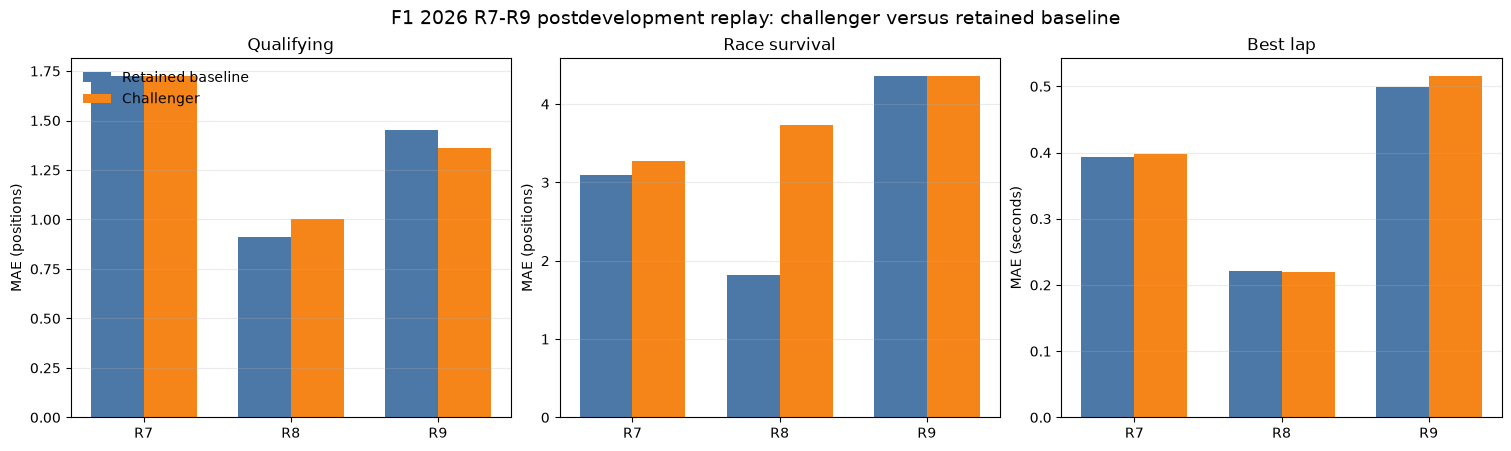

PosixPath('/Users/lemonnierhugo/Desktop/Coding Project/Sport Prediction/docs/research/assets/f1_model_research_v2_comparison.png')

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
colors = {'baseline': '#4C78A8', 'candidate': '#F58518'}
for axis, mode in zip(axes, ['Qualifying', 'Race survival', 'Best lap']):
    frame = audit_comparison.loc[audit_comparison['mode'].eq(mode)].sort_values('round')
    x = np.arange(len(frame))
    width = 0.36
    axis.bar(x - width / 2, frame['baseline'], width, label='Retained baseline', color=colors['baseline'])
    axis.bar(x + width / 2, frame['candidate'], width, label='Challenger', color=colors['candidate'])
    axis.set_xticks(x, [f"R{value}" for value in frame['round']])
    axis.set_title(mode)
    axis.set_ylabel(f"MAE ({frame['unit'].iloc[0]})")
    axis.grid(axis='y', alpha=0.25)
axes[0].legend(frameon=False, loc='upper left')
fig.suptitle('F1 2026 R7-R9 postdevelopment replay: challenger versus retained baseline', fontsize=14)
chart_path = ASSETS / 'f1_model_research_v2_comparison.png'
fig.savefig(chart_path, dpi=180, bbox_inches='tight')
plt.show()
chart_path

In [8]:
probability = payloads['qualifying_probability']['aggregate_audit']
telemetry = payloads['telemetry_sequence']['summary']
residual = payloads['same_season_residual']['audit_metrics']
tcn = payloads['telemetry_tcn']['summary']
tcn_matrix = payloads['telemetry_tcn_matrix']
live = payloads['live_next_lap']
strategy_replay = payloads['live_strategy_replay']
summary = {
    'qualifying': {
        'all_round_baseline_mae_positions': q['aggregate']['baseline_mean_mae'],
        'all_round_research_candidate_mae_positions': q['aggregate']['candidate_mean_mae_all_rounds_with_baseline_substitution'],
        'all_round_public_output_mae_positions': q['aggregate']['selected_output_mean_mae'],
        'audit_baseline_mae_positions': q['aggregate']['audit_baseline_mean_mae'],
        'audit_candidate_mae_positions': q['aggregate']['audit_candidate_mean_mae'],
        'audit_public_output_mae_positions': q['aggregate']['audit_selected_output_mean_mae'],
        'research_selection_winner_model_id': q['promotion']['selection_block_winner_model_id'],
        'public_output_model_id': q['promotion']['selected_public_output_model_id'],
        'research_selected_point_head': q['promotion']['selected_challenger_point_head'],
        'evidence_role': q['protocol']['evidence_role'],
        'prospective_development_evidence': q['protocol']['prospective_development_evidence'],
        'promoted': q['promotion']['promoted'],
    },
    'qualifying_probability': {
        'raw_log_loss': probability['jeffreys_smoothed_uncalibrated']['multiclass_log_loss'],
        'calibrated_log_loss': probability['calibrated']['multiclass_log_loss'],
        'raw_brier': probability['jeffreys_smoothed_uncalibrated']['normalized_multiclass_brier'],
        'calibrated_brier': probability['calibrated']['normalized_multiclass_brier'],
        'promoted': payloads['qualifying_probability']['promoted'],
    },
    'race_main_survival': {
        'scored_rounds': 7,
        'audit_baseline_mae_positions': r_main['audit_aggregate']['baseline_mean_mae'],
        'audit_candidate_mae_positions': r_main['audit_aggregate']['candidate_mean_mae'],
        'selected_model_id': r_main_rows['selected_model_id'].iloc[0],
        'evidence_role': r_main['protocol']['evidence_role'],
        'prospective_development_evidence': r_main['protocol']['prospective_development_evidence'],
        'promoted': r_main['promotion']['promoted'],
    },
    'race_certified_grid_prior': {
        'scored_rounds': 9,
        'all_round_baseline_mae_positions': r_certified['aggregate']['baseline_mean_mae'],
        'all_round_candidate_mae_positions': r_certified['aggregate']['candidate_mean_mae'],
        'audit_baseline_mae_positions': r_certified['audit_aggregate']['baseline_mean_mae'],
        'audit_candidate_mae_positions': r_certified['audit_aggregate']['candidate_mean_mae'],
        'selected_model_id': r_certified_rows['selected_model_id'].iloc[0],
        'venue_timezones': sorted({event['certified_grid_evidence']['pinned_document_timezone'] for event in r_certified['events']}),
        'max_observed_publication_lag_seconds': max(float(event['certified_grid_evidence']['publication_lag_seconds']) for event in r_certified['events']),
        'maximum_allowed_publication_lag_seconds': min(float(event['certified_grid_evidence']['maximum_allowed_publication_lag_seconds']) for event in r_certified['events']),
        'all_logical_horizons_certified': all(bool(event['certified_grid_evidence']['logical_horizon_certified_by_authoritative_publication_time']) for event in r_certified['events']),
        'promoted': r_certified['promotion']['promoted'],
    },
    'best_lap': {
        'audit_baseline_mae_seconds': b['aggregate']['conditional_event_mean_baseline_p50_mae_seconds'],
        'audit_candidate_mae_seconds': b['aggregate']['conditional_event_mean_p50_mae_seconds'],
        'baseline_interval_coverage': b['aggregate']['baseline_interval_coverage'],
        'candidate_interval_coverage': b['aggregate']['interval_coverage'],
        'baseline_interval_width_seconds': b['aggregate']['baseline_interval_mean_width_seconds'],
        'candidate_interval_width_seconds': b['aggregate']['interval_mean_width_seconds'],
        'point_promoted': b['decision']['full_mode_point_promoted'],
        'interval_promoted': b['decision']['probabilistic_intervals_promoted'],
        'evidence_role': b['protocol']['evidence_role'],
        'prospective_development_evidence': b['protocol']['prospective_development_evidence'],
    },
    'same_season_residual': {
        'raw_rehearsal_mae_seconds': residual['best_lap_raw_rehearsal']['best_lap_event_mean_mae_seconds'],
        'ridge_mae_seconds': residual['best_lap_selected']['best_lap_event_mean_mae_seconds'],
        'ridge_model_id': residual['best_lap_selected']['model_id'],
        'evidence_role': payloads['same_season_residual']['protocol']['evidence_role'],
        'prospective_development_evidence': payloads['same_season_residual']['protocol']['prospective_development_evidence'],
    },
    'telemetry_sequence': {
        'raw_mae_seconds': telemetry['raw_baseline']['event_balanced_mae_seconds'],
        'source_shift_mae_seconds': telemetry['source_shift_baseline']['event_balanced_mae_seconds'],
        'temporal_mae_seconds': telemetry['temporal_ridge_or_zero']['event_balanced_mae_seconds'],
        'temporal_incremental_gain': telemetry['temporal_ridge_or_zero']['relative_improvement_vs_source_shift_baseline'],
    },
    'telemetry_tcn': {
        'reference_source_shift_mae_seconds': tcn['source_shift_baseline']['event_balanced_mae_seconds'],
        'reference_tcn_mae_seconds': tcn['tcn_driver_correction']['event_balanced_mae_seconds'],
        'reference_tcn_minus_source_shift_seconds': tcn['paired_event_tcn_vs_source_shift']['mean_delta_seconds'],
        'locked_selected_policy_mae_seconds': tcn['locked_selected_policy']['event_balanced_mae_seconds'],
        'fixed_seed_mean_absolute_event_delta_seconds': tcn_matrix['comparisons']['reference_vs_fixed_seed_repeat']['mean_absolute_event_delta_seconds'],
        'telemetry_minus_sham_mean_event_mae_seconds': tcn_matrix['comparisons']['reference_vs_equal_architecture_zero_telemetry_sham']['mean_delta_seconds'],
        'promotion_eligible': payloads['telemetry_tcn']['promotion_eligible'],
    },
    'evidence_integrity': {
        'registered_artifacts': int(len(artifact_register)),
        'artifacts_passed': int(artifact_register['provenance_closure_status'].eq('pass').sum()),
        'implementation_manifest_direct_entries': int(artifact_register['implementation_manifest_direct_entries'].sum()),
        'input_manifest_direct_entries': int(artifact_register['input_manifest_direct_entries'].sum()),
        'transitive_file_references': int(artifact_register['transitive_file_count'].sum()),
        'nested_json_references': int(artifact_register['nested_json_count'].sum()),
        'aggregate_manifest_digests_checked': int(artifact_register['aggregate_manifest_digest_count'].sum()),
        'status': 'pass' if artifact_register['provenance_closure_status'].eq('pass').all() else 'fail',
    },
    'live_next_lap': {
        'matched_forecasts': live['aggregate']['rows'],
        'blend_mae_seconds': live['aggregate']['event_mean_blend_mae_seconds'],
        'naive_mae_seconds': live['aggregate']['event_mean_naive_mae_seconds'],
        'paired_delta_seconds': live['aggregate']['paired_blend_vs_naive']['mean_delta_seconds'],
        'paired_ci95_seconds': live['aggregate']['paired_blend_vs_naive']['ci95_seconds'],
        'adaptive_blend_retained': live['decision']['point_forecast_retained'],
        'public_forecast': 'naive_next_lap_baseline',
    },
    'live_strategy_replay': {
        'state_contract': strategy_replay['contracts']['state'],
        'transition_contract': strategy_replay['contracts']['transition_fingerprint'],
        'dataset_contract': strategy_replay['contracts']['rl_replay_dataset'],
        'legal_action_mask_contract': strategy_replay['contracts']['legal_action_mask'],
        'legality_semantics': strategy_replay['contracts']['legality_semantics'],
        'operational_fallback_semantics': strategy_replay['contracts']['operational_fallback_semantics'],
        'transitions': strategy_replay['aggregate']['transitions'],
        'behavior_cloning_rows': strategy_replay['aggregate']['behavior_cloning_rows'],
        'offline_q_rows': strategy_replay['aggregate']['offline_q_rows'],
        'propensity_ope_rows': strategy_replay['aggregate']['propensity_ope_rows'],
        'compatible_action_key_count': strategy_replay['aggregate']['behavior_cloning_action_support']['compatible_action_key_count'],
        'exact_action_key_count': strategy_replay['aggregate']['behavior_cloning_action_support']['exact_action_key_count'],
        'action_family_counts': strategy_replay['aggregate']['action_family_counts'],
        'reward_components_fully_observed_rows': strategy_replay['aggregate']['reward']['reward_components_fully_observed_rows'],
        'reward_components_incomplete_rows': strategy_replay['aggregate']['reward']['reward_components_incomplete_rows'],
        'rolling_bc_action_accuracy': strategy_replay['behavior_cloning']['event_mean_candidate_metrics']['action_selection_accuracy'],
        'rolling_trivial_action_accuracy': strategy_replay['behavior_cloning']['event_mean_trivial_baseline_metrics']['action_selection_accuracy'],
        'rolling_bc_pit_f1': strategy_replay['behavior_cloning']['event_mean_candidate_metrics']['pit_decision_f1'],
        'strategy_training_readiness_gate_pass': strategy_replay['aggregate']['strategy_training_readiness_gate_pass'],
        'rl_policy_promoted': strategy_replay['decision']['rl_policy_promoted'],
    },
}
summary

{'qualifying': {'all_round_baseline_mae_positions': 1.8686868686868685,
  'all_round_research_candidate_mae_positions': 1.8585858585858586,
  'all_round_public_output_mae_positions': 1.8686868686868685,
  'audit_baseline_mae_positions': 1.3636363636363635,
  'audit_candidate_mae_positions': 1.3636363636363635,
  'audit_public_output_mae_positions': 1.3636363636363635,
  'research_selection_winner_model_id': 'shared_qualifying_latent_lap_v4',
  'public_output_model_id': 'qualifying_rehearsal_rank_baseline_v1',
  'research_selected_point_head': 'joint_minimum_expected_absolute_position_loss_assignment',
  'evidence_role': 'postdevelopment_replay_diagnostic_after_prior_R7_R9_inspection',
  'prospective_development_evidence': False,
  'promoted': False},
 'qualifying_probability': {'raw_log_loss': 2.847352486626994,
  'calibrated_log_loss': 2.834998795650037,
  'raw_brier': 0.46776106221121433,
  'calibrated_brier': 0.46798753033180224,
  'promoted': False},
 'race_main_survival': {'scored

In [9]:
qualifying_detail = q_rows[[
    'round', 'event_key', 'event_name', 'forecast_phase', 'driver_id',
    'baseline_rank_prior', 'minimum_expected_absolute_loss_predicted_qualifying_position',
    'research_selected_predicted_qualifying_position',
    'public_output_predicted_qualifying_position', 'actual_qualifying_position',
    'selection_block_winner_model_id', 'public_output_model_id',
]].rename(columns={
    'forecast_phase': 'role',
    'baseline_rank_prior': 'baseline_predicted_position',
    'minimum_expected_absolute_loss_predicted_qualifying_position': 'candidate_predicted_position',
    'research_selected_predicted_qualifying_position': 'research_selected_predicted_position',
    'public_output_predicted_qualifying_position': 'public_predicted_position',
    'actual_qualifying_position': 'actual_position',
})
qualifying_detail['baseline_absolute_error'] = (qualifying_detail['baseline_predicted_position'] - qualifying_detail['actual_position']).abs()
qualifying_detail['candidate_absolute_error'] = (qualifying_detail['candidate_predicted_position'] - qualifying_detail['actual_position']).abs()
qualifying_detail['research_selected_absolute_error'] = (qualifying_detail['research_selected_predicted_position'] - qualifying_detail['actual_position']).abs()
qualifying_detail['public_absolute_error'] = (qualifying_detail['public_predicted_position'] - qualifying_detail['actual_position']).abs()

race_detail = r_certified_rows[[
    'round', 'event_key', 'event_name', 'partition', 'driver_id', 'grid_baseline_position',
    'candidate_predicted_position', 'selected_predicted_position', 'actual_position',
    'selected_model_id', 'driver_residual_effect', 'team_residual_effect',
    'prior_driver_events', 'prior_team_events',
]].copy()
race_detail = race_detail.rename(columns={'partition': 'role'})
race_detail.insert(0, 'evidence_product', 'certified_grid_plus_prior_race_state')
race_detail['baseline_absolute_error'] = (race_detail['grid_baseline_position'] - race_detail['actual_position']).abs()
race_detail['candidate_absolute_error'] = (race_detail['candidate_predicted_position'] - race_detail['actual_position']).abs()
race_detail['selected_absolute_error'] = (race_detail['selected_predicted_position'] - race_detail['actual_position']).abs()

race_main_detail = r_main_rows[[
    'round', 'event_key', 'event_name', 'driver_id', 'grid_baseline_position',
    'candidate_predicted_position', 'selected_predicted_position', 'finish_position',
    'selected_model_id', 'terminal_status', 'candidate_terminal_probability',
    'selected_terminal_probability',
]].rename(columns={'finish_position': 'actual_position'})
race_main_detail['baseline_absolute_error'] = (race_main_detail['grid_baseline_position'] - race_main_detail['actual_position']).abs()
race_main_detail['candidate_absolute_error'] = (race_main_detail['candidate_predicted_position'] - race_main_detail['actual_position']).abs()
race_main_detail['selected_absolute_error'] = (race_main_detail['selected_predicted_position'] - race_main_detail['actual_position']).abs()

best_detail_frames = []
for event in b['events']:
    frame = pd.DataFrame(event['prediction_vs_reality'])[[
        'event_key', 'driver_id', 'baseline_lap_p50', 'lap_p05', 'lap_p50', 'lap_p90',
        'achievable_session_end_lap_time_seconds', 'baseline_absolute_error_seconds',
        'challenger_absolute_error_seconds', 'target_observed',
    ]].copy()
    frame.insert(0, 'role', event['event_partition_role'])
    frame.insert(0, 'round', int(event['round']))
    frame = frame.rename(columns={'achievable_session_end_lap_time_seconds': 'actual_best_lap_seconds'})
    best_detail_frames.append(frame)
best_lap_detail = pd.concat(best_detail_frames, ignore_index=True)

qualifying.to_csv(EVIDENCE / 'f1_qualifying_round_results_2026.csv', index=False)
qualifying_detail.to_csv(EVIDENCE / 'f1_qualifying_prediction_vs_reality_2026.csv', index=False)
race.to_csv(EVIDENCE / 'f1_race_round_results_2026.csv', index=False)
race_detail.to_csv(EVIDENCE / 'f1_race_prediction_vs_reality_2026.csv', index=False)
race_main.to_csv(EVIDENCE / 'f1_race_survival_round_results_2026.csv', index=False)
race_main_detail.to_csv(EVIDENCE / 'f1_race_survival_prediction_vs_reality_2026.csv', index=False)
best_lap.to_csv(EVIDENCE / 'f1_best_lap_round_results_2026.csv', index=False)
best_lap_detail.to_csv(EVIDENCE / 'f1_best_lap_prediction_vs_reality_2026.csv', index=False)
audit_long.to_csv(EVIDENCE / 'f1_audit_comparison_long_2026.csv', index=False)
artifact_register.to_csv(EVIDENCE / 'f1_model_research_v2_artifact_register.csv', index=False)
(EVIDENCE / 'f1_model_research_v2_summary.json').write_text(
    json.dumps(summary, indent=2, sort_keys=True, allow_nan=False) + '\n',
    encoding='utf-8',
)
assert set(qualifying_detail['round']) == set(range(1, 10)) and len(qualifying_detail) == 198
assert set(race_detail['round']) == set(range(1, 10)) and len(race_detail) == 198
assert set(best_lap_detail['round']) == set(range(1, 10)) and len(best_lap_detail) == 198
{
    'qualifying_round_rows': len(qualifying),
    'qualifying_driver_rows': len(qualifying_detail),
    'race_round_rows': len(race),
    'race_driver_rows': len(race_detail),
    'race_main_survival_round_rows': len(race_main),
    'race_main_survival_driver_rows': len(race_main_detail),
    'best_lap_round_rows': len(best_lap),
    'best_lap_driver_rows': len(best_lap_detail),
    'audit_chart': str(chart_path.relative_to(ROOT)),
    'artifacts': len(artifact_register),
}

{'qualifying_round_rows': 9,
 'qualifying_driver_rows': 198,
 'race_round_rows': 9,
 'race_driver_rows': 198,
 'race_main_survival_round_rows': 7,
 'race_main_survival_driver_rows': 154,
 'best_lap_round_rows': 9,
 'best_lap_driver_rows': 198,
 'audit_chart': 'docs/research/assets/f1_model_research_v2_comparison.png',
 'artifacts': 11}